___

**[ Machine Learning in Geosciences ]**

**Department of Applied Geoinformatics and Carthography, Charles University** 

*Lukas Brodsky lukas.brodsky@natur.cuni.cz*


___

**Exercise: make assumption from data -> select ML algorithm**

**Task**: 
* Don’t pick algorithms from memory.
* Diagnose the data-generating process and justify the model.

There are 5 generated synthetic geoscience datasets, each violating a different assumption.

**You must**:
1. Inspect data (plots)
2. Choose model
3. Train
4. Evaluate
5. Explain why it works

All datasets are low-dimensional → visual intuition first.

**Imports**

In [39]:
# Common imports & ML models 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error

# Linear regression 
from sklearn.linear_model import LinearRegression
# KNN 
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
# DT 
from sklearn.tree import DecisionTreeClassifier
# SVM 
from sklearn.svm import SVC
# ANN - MLP 
from sklearn.neural_network import MLPClassifier
# clustering DBSCAN 
from sklearn.cluster import DBSCAN

In [54]:
def plot_decision_boundary(model, X, y, title="Model", resolution=300):

    n_features = model.n_features_in_

    # ---- 1D ----
    if n_features == 1:
        xs = np.linspace(X.min()-1, X.max()+1, resolution).reshape(-1,1)

        if hasattr(model, "predict_proba"):
            preds = model.predict_proba(xs)[:,1]
        else:
            preds = model.predict(xs)

        plt.figure(figsize=(6,4))
        plt.scatter(X[:,0], y, c=y, cmap="coolwarm", s=25)
        plt.plot(xs, preds, color="black", linewidth=2)
        plt.title(title)
        plt.show()
        return

    # ---- 2D ----
    if n_features == 2:
        x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
        y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, resolution),
            np.linspace(y_min, y_max, resolution)
        )

        grid = np.c_[xx.ravel(), yy.ravel()]
        Z = model.predict(grid).reshape(xx.shape)

        plt.figure(figsize=(6,5))
        plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
        plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", edgecolor="k")
        plt.title(title)
        plt.show()

# **Dataset A**

Temperature vs elevation

In [3]:
# Data
np.random.seed(0)
x = np.random.uniform(0, 3000, 150)
y = 15 - 0.0065*x + np.random.normal(0, 1.0, 150)

X = x.reshape(-1,1)
Xtr,Xte,Ytr,Yte = train_test_split(X,y,test_size=0.3)

In [5]:
Xtr.shape

(105, 1)

In [7]:
Ytr.shape

(105,)

In [8]:
Xte.shape

(45, 1)

In [9]:
Yte.shape

(45,)

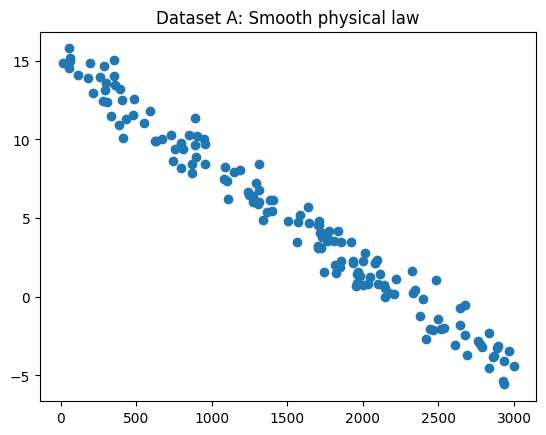

In [10]:
# Data plot 
plt.scatter(x,y)
# plt.plot(np.sort(x), lr.predict(np.sort(X,axis=0)), color='red')
plt.title("Dataset A: Smooth physical law")
plt.show()

**What is the global relation?**  → LINEAR

In [14]:
# Select model and create an instance 
model = LinearRegression()
# Model fit 
model.fit(Xtr, Ytr)
# Model prediction 
Y_pred = model.predict(Xte)
# Model evaluation
mean_squared_error(Yte, Y_pred)

0.6897677208791585

In [13]:
# Y_pred

array([-2.1170644 ,  6.02885575,  2.84291276,  9.29761626,  7.4599619 ,
       -3.81118411,  6.85331188,  3.7028537 ,  6.42812744,  3.14311442,
        4.20499385,  6.84545955,  5.82887079, 10.02166435, -3.21111754,
       13.09591252,  1.88335555, 10.61627828,  2.15036908,  4.59704547,
        3.78867695,  6.20649126,  9.15276446,  6.6645143 ,  7.93104025,
        3.85487887,  7.77251635, -0.35579744, -4.65288295, -1.65248415,
        0.73216206, -4.44674266,  2.95942859,  8.79864504, 12.67916764,
        2.33165901,  1.5870603 , -1.38108273, -2.54833623,  7.84831639,
       -0.30910169, 13.03439203, 12.287314  ,  9.07132007,  0.53652104])

In [17]:
X_sim = np.linspace(0, 3000, 100)

In [22]:
X_sim.reshape(-1,1).shape

(100, 1)

In [21]:
Xtr.shape

(105, 1)

In [23]:
# How? 
Y_pred_sim = model.predict(X_sim.reshape(-1,1))

In [24]:
Y_pred_sim

array([15.00712831, 14.80831311, 14.6094979 , 14.4106827 , 14.21186749,
       14.01305229, 13.81423708, 13.61542188, 13.41660667, 13.21779147,
       13.01897626, 12.82016106, 12.62134585, 12.42253065, 12.22371544,
       12.02490024, 11.82608503, 11.62726983, 11.42845462, 11.22963942,
       11.03082421, 10.83200901, 10.6331938 , 10.4343786 , 10.23556339,
       10.03674819,  9.83793298,  9.63911778,  9.44030257,  9.24148737,
        9.04267216,  8.84385696,  8.64504175,  8.44622655,  8.24741134,
        8.04859614,  7.84978093,  7.65096573,  7.45215052,  7.25333532,
        7.05452011,  6.85570491,  6.6568897 ,  6.4580745 ,  6.25925929,
        6.06044409,  5.86162888,  5.66281368,  5.46399847,  5.26518327,
        5.06636806,  4.86755286,  4.66873765,  4.46992245,  4.27110724,
        4.07229204,  3.87347683,  3.67466163,  3.47584642,  3.27703122,
        3.07821601,  2.87940081,  2.6805856 ,  2.4817704 ,  2.28295519,
        2.08413999,  1.88532478,  1.68650958,  1.48769437,  1.28

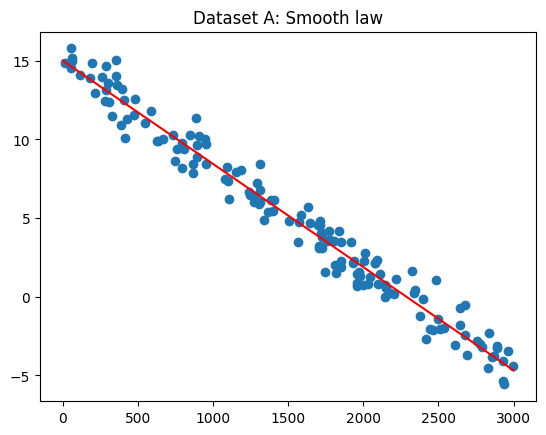

In [27]:
# Model plot
plt.scatter(x,y)
plt.plot(X_sim, Y_pred_sim, color='red')
plt.title("Dataset A: Smooth law")
plt.show()

# **Dataset B** 


In [6]:
# Data: environmental feature space (3 variables)
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2)
n = 300

# environmental feature space
c1 = np.random.normal(loc=[-2,-1], scale=0.6, size=(n//3,2))
c2 = np.random.normal(loc=[2,1.5], scale=0.7, size=(n//3,2))
c3 = np.random.normal(loc=[0,3], scale=0.5, size=(n//3,2))

X = np.vstack([c1,c2,c3])

In [7]:
X.shape

(300, 2)

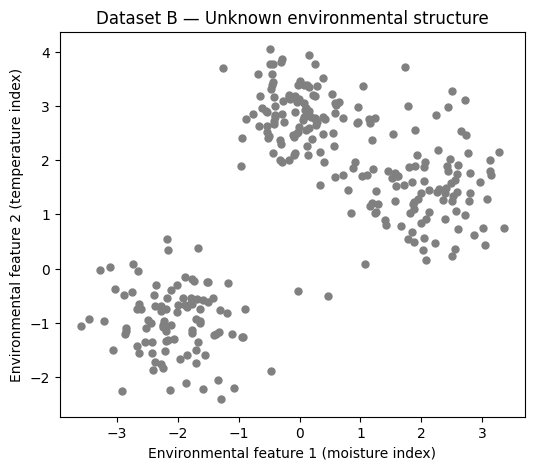

In [8]:
# Plot data 
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], color="gray", s=25)
plt.xlabel("Environmental feature 1 (moisture index)")
plt.ylabel("Environmental feature 2 (temperature index)")
plt.title("Dataset B — Unknown environmental structure")
plt.show()

In [20]:
from sklearn.cluster import DBSCAN
# Select model and create an instance 
model = DBSCAN(eps=1.0) # eps=0.5
# Model fit 
model.fit(X)
# prediction 
y_labels = model.fit_predict(X)

In [21]:
model

DBSCAN(eps=1.0)

In [22]:
np.unique(model.labels_)

array([0, 1])

In [23]:
# model.labels_

In [24]:
y_labels = model.fit_predict(X)

In [25]:
# y_labels

In [26]:
# plot_decision_boundary(model, X, y_labels, "similarity-based classification")

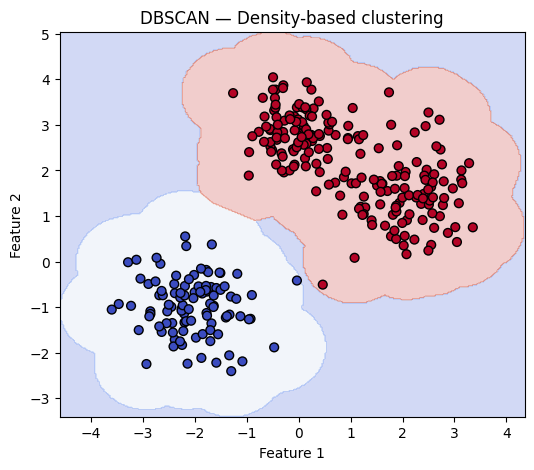

In [27]:
# Decision boundary for DBSCAN 
from scipy.spatial.distance import cdist 

# core samples
core_points = X[model.core_sample_indices_]
core_labels = y_labels[model.core_sample_indices_]

# -----------------------------
# Create grid for visualization
# -----------------------------
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# -----------------------------
# Assign grid points to clusters
# -----------------------------
distances = cdist(grid, core_points)

nearest_core = distances.argmin(axis=1)
nearest_dist = distances.min(axis=1)

Z = np.full(len(grid), -1)

for i in range(len(grid)):
    if nearest_dist[i] <= model.eps:
        Z[i] = core_labels[nearest_core[i]]

Z = Z.reshape(xx.shape)

# -----------------------------
# Plot decision regions
# -----------------------------
plt.figure(figsize=(6,5))

plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")

plt.scatter(
    X[:,0], X[:,1],
    c=y_labels,
    cmap="coolwarm",
    edgecolor="k",
    s=40
)

plt.title("DBSCAN — Density-based clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# **Dataset C**

In [56]:
# Data 
np.random.seed(3)
n = 400

# environmental variables
elevation = np.random.uniform(0,3000,n)
moisture = np.random.uniform(0,1,n)

X = np.column_stack([elevation, moisture])

# environmental regimes
y = np.zeros(n)
# agriculture
y[(elevation < 800) & (moisture > 0.4)] = 0
# forest
y[(elevation >= 800) & (elevation < 1800)] = 1
# rock
y[(elevation >= 1800) & (moisture < 0.5)] = 2
# snow
y[(elevation >= 1800) & (moisture >= 0.5)] = 3

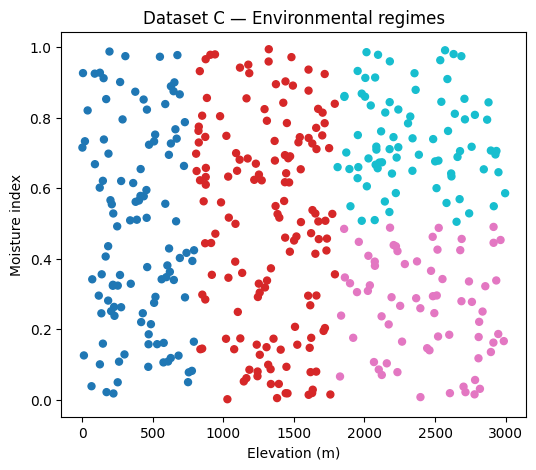

In [57]:
plt.figure(figsize=(6,5))
plt.scatter(elevation, moisture, c=y, cmap="tab10", s=25)

plt.xlabel("Elevation (m)")
plt.ylabel("Moisture index")
plt.title("Dataset C — Environmental regimes")
plt.show()

In [ ]:
# Select model and create an instance 
pass 
# Model fit 
pass 
# Model prediction 
pass

# Model evaluation
pass

In [ ]:
# Plot 
plot_decision_boundary(model, X, y, title="Model", resolution=300)

# **Dataset D**

In [58]:
from sklearn.datasets import make_blobs
X,y = make_blobs(n_samples=300,centers=2,cluster_std=1.3,random_state=4)

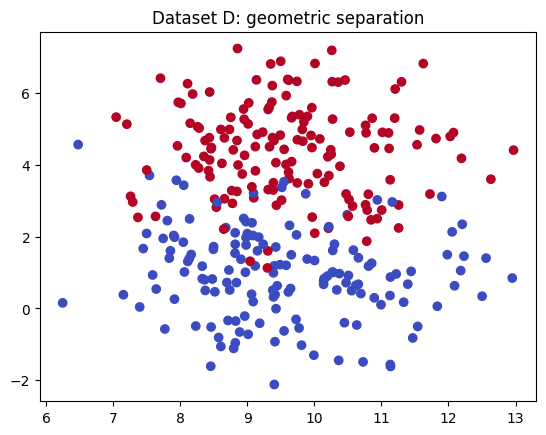

In [59]:
plt.scatter(X[:,0],X[:,1],c=y,cmap="coolwarm")
plt.title("Dataset D: geometric separation")
plt.show()

In [ ]:
# Select model and create an instance 
pass 
# Model fit 
pass 
# Model prediction 
pass 
# Model evaluation
pass

In [ ]:
# plot decision boundary 

# **Dataset E**

In [60]:
from sklearn.datasets import make_moons
X,y = make_moons(n_samples=300,noise=0.2,random_state=5)

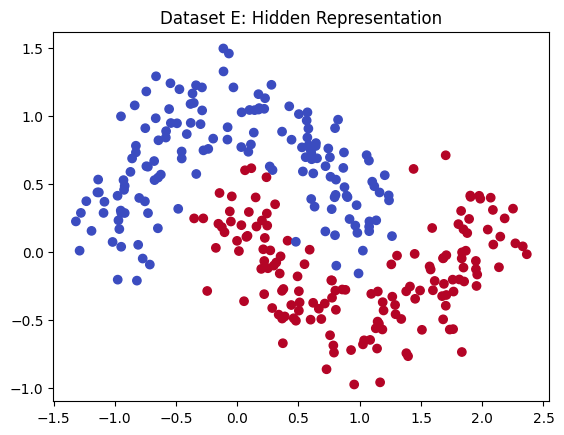

In [61]:
plt.scatter(X[:,0],X[:,1],c=y,cmap="coolwarm")
plt.title("Dataset E: Hidden Representation")
plt.show()

**XOR — classic “feature missing” problem** 

In [ ]:
# Select model and create an instance 
pass 
# Model fit 
pass 
# Model prediction 
pass 

# Model evaluation
pass


In [ ]:
# plot 
# plot_decision_boundary(model,X,y,"Model")